In [1]:
""" !pip install -r requirements.txt """

' !pip install -r requirements.txt '

# Import Libraries

In [2]:
import os
import time
import pickle
import random
import itertools

# Analisi dati e Visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing e Dimensionality Reduction
from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler,
    LabelEncoder,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

# Scikit-learn: Model Selection e Pipeline
from sklearn.model_selection import (
    train_test_split,
    PredefinedSplit,
    GridSearchCV,
    RandomizedSearchCV,
    ParameterGrid
)
from sklearn.pipeline import Pipeline

# Scikit-learn: Modelli di Machine Learning Classico
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import plot_tree

# Imbalanced Learning (SMOTE e Pipeline compatibile)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Metriche di Valutazione
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    PrecisionRecallDisplay
)

# Deep Learning (PyTorch) e Monitoraggio
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import datetime

# Our packages
from utils import *
from plot import *

# Global Variables

In [3]:
seed = 42
FILENAME = "../../data/train.csv"

# Load the dataset

In [4]:
df = pd.read_csv(FILENAME, encoding='ISO-8859-1', sep=",")

rows = df.shape[0]
cols = df.shape[1]
print("# Righe: " + str(rows)+ " # Colonne: "+str(cols) + "\n")

# Righe: 148301 # Colonne: 145



# Preprocessing

## 1. Remove duplicates rows and columns

In [5]:
# Individua se esistono colonne con lo stesso nome
# Se esistono, allora se le colonne sono duplicati perfetti, droppiamo il duplicato
# Se esistono, ma nono sono perfetti duplicati, per intervenire consciamente sarebbe necessario avere maggior domain knowledge
feature_list = df.columns.to_list()
has_duplicate_cols = len(feature_list) != len(set(feature_list))
print("Ci sono colonne con lo stesso nome?", has_duplicate_cols)

if has_duplicate_cols:
    df2 = df.T.drop_duplicates().T


# Rimuovi righe duplicate
df.drop_duplicates(inplace=True)


##################################################
print("Nuovo # Righe: " + str(rows)+ " Nuovo # Colonne: "+str(cols) + "\n")


Ci sono colonne con lo stesso nome? False
Nuovo # Righe: 148301 Nuovo # Colonne: 145



## 2. Label extraction

In [6]:
X = df.drop(columns=["grade"])
y = df["grade"]

## 3. Data visualization

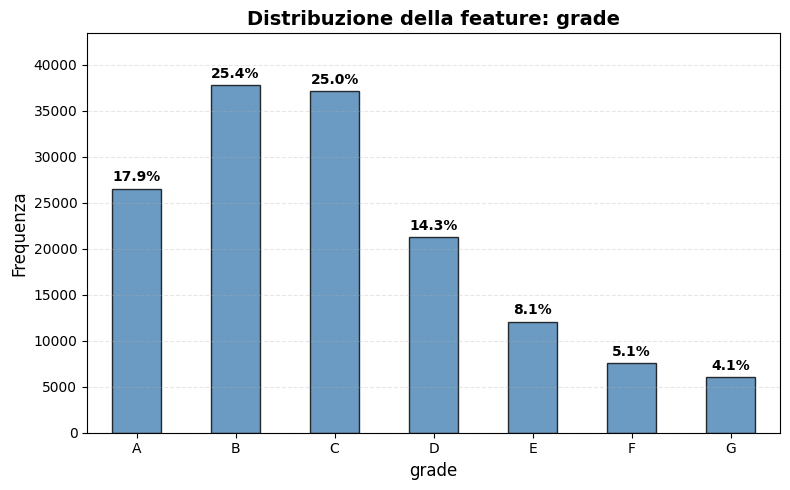

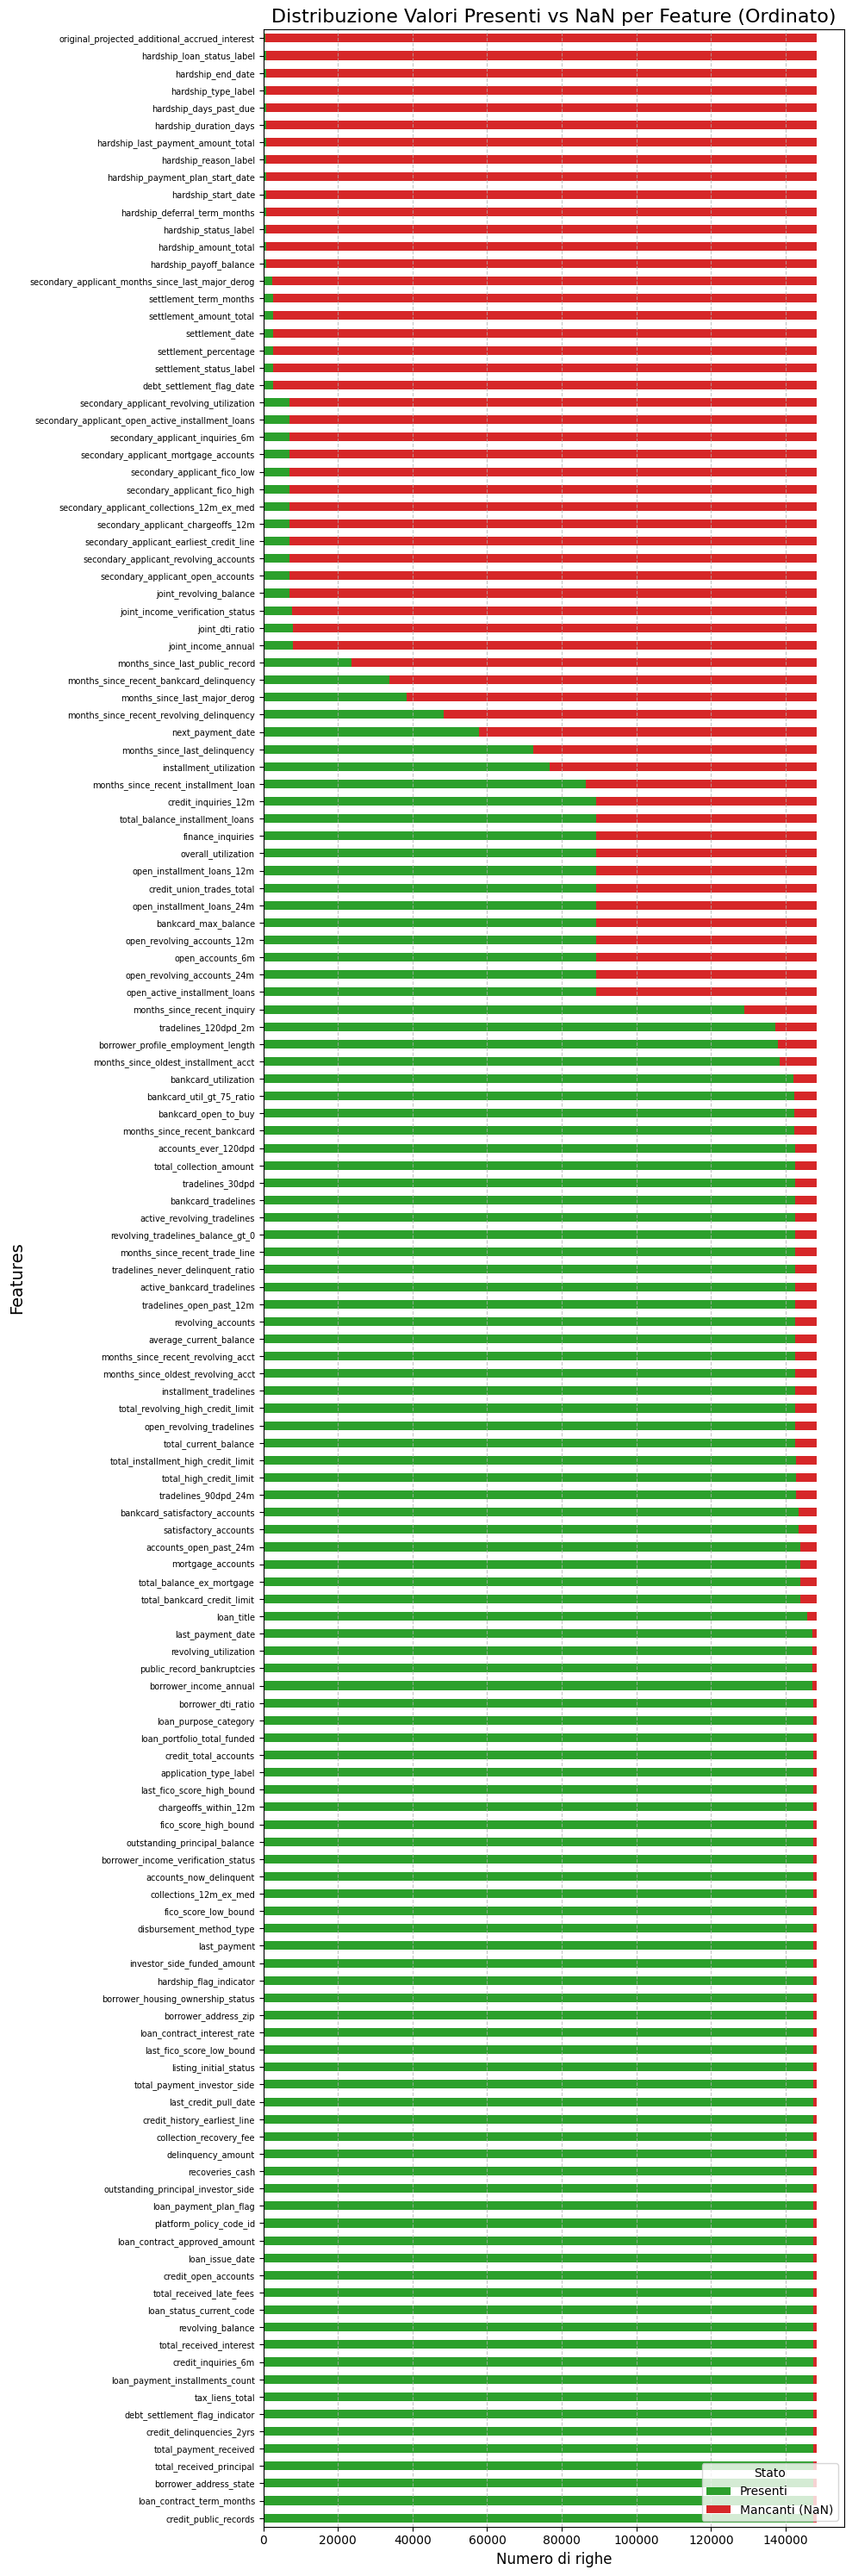

In [7]:
plot_feature_distribution(y, "grade")
plot_nan(X)

## 4. Features manipulation

In [8]:
for i in X.dtypes.unique():
    print("Type", i)

Type float64
Type str


### Drop leakange and non significant features

In [9]:
loan_performance_data_leakage = [
    'loan_status_current_code',                         # prestito in regola, in ritardo, totalmente pagato...
    'outstanding_principal_balance',                    # "outstanding principal" e' la parte del capitale da restituire
    'outstanding_principal_investor_side',              # similmente
    'total_payment_received',                           # somma pagata al creditore
    'total_payment_investor_side',
    'total_received_principal',                         # somma pagata al creditore che copre la il capitale del prestito
    'total_received_interest',                          # ... copre gli interessi
    'total_received_late_fees',                         # ... copre le penali
    'recoveries_cash',                                  # somma recuperata dopo un prestito andato in default
    'collection_recovery_fee',                          # spese per il recupero crediti
    'last_payment_date',                                # data ultimo pagamento effettuato
    'last_payment',                                     # importo ultimo pagamento
    'next_payment_date',                                # data prossimo pagamento
    'last_credit_pull_date',                            # data ultimo check profilo creditizio, durante il periodo di prestito
    'last_fico_score_high_bound',                       # ultimo punteggio FICO rilevato: al momento della concessione del prestito si usa 'fico_score_low_bound', 'fico_score_high_bound
    'last_fico_score_low_bound',
    'total_collection_amount',
    'loan_payment_installments_count'                   # potrebbe semprare il numero di rate, ma la tipologia di valori contenuti fa pensare al valore economico della singola rata (calcolo derivante di interest rate)
]


# "Settlement" indica una situazione avvenuta durante / dopo il prestito, non al momento della concessione
settlement_data_leakage = [col for col in X.columns if 'settlement' in col]


# "Hardship loans" sono concessioni per agevolare il pagamento di un prestito quando il debitore si trova in momenti di difficoltà economica (perdita lavoro, problemi medici, disastri naturali)
# https://www.oaic.gov.au/privacy/your-privacy-rights/credit-reporting/hardship-assistance/what-is-a-financial-hardship-arrangement
# https://financialrights.org.au/factsheet/financial-hardship/
hardship_data_leakage = [col for col in X.columns if 'hardship' in col]


other_leakage = [
    'original_projected_additional_accrued_interest',           # interesse addizionale previsto, presumibilmente in seguito a modifiche di piani ammortamento o hardship
    #'loan_issue_date',                                         # Il grade è influenzato dalla situazione creditizia del richiedente, più che dal periodo
                                                                # droppato in un secondo momento, dopo averlo usato per feature extraction
    'investor_side_funded_amount',
    'loan_portfolio_total_funded',
]


# Il tasso di interesse di un prestito è calcolato basandosi sul Grading assegnato al prestito stesso.
# Essendo una conseguenza del nostro target "grade", è da considerarsi data leakage
# https://www.airtel.in/blog/personal-loan/how-does-loan-grading-work/ (Accessed 02/02/2026)
loan_contract_interest_rate = [
    'loan_contract_interest_rate'
]

# DROP OPERATIONS
X.drop(columns=loan_performance_data_leakage, inplace=True)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

X.drop(columns=settlement_data_leakage, inplace=True)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

X.drop(columns=hardship_data_leakage, inplace=True)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

X.drop(columns=other_leakage, inplace=True)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

X.drop(columns=loan_contract_interest_rate, inplace=True)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")



Nuovo # Colonne: 126

Nuovo # Colonne: 119

Nuovo # Colonne: 105

Nuovo # Colonne: 102

Nuovo # Colonne: 101



In [10]:
other_non_significant = [
    'platform_policy_code_id',                                      # id interno al prestatore
    'loan_title',                                                   # non significant column, grande sparsita' di dati. Sufficiente loan_purpose_category come aggregazione di scopo del prestito
    'borrower_address_zip',                                         # non significant column, esiste una colonna per identificazione stati
]

X.drop(columns=other_non_significant, inplace=True)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Nuovo # Colonne: 98



### Drop high Nan features

In [11]:
X = drop_high_nan_columns(X, 0.90)

##################################################
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

Colonne rimosse (> 90.0% NaN):
['joint_income_annual', 'joint_dti_ratio', 'joint_income_verification_status', 'joint_revolving_balance', 'secondary_applicant_fico_low', 'secondary_applicant_fico_high', 'secondary_applicant_earliest_credit_line', 'secondary_applicant_inquiries_6m', 'secondary_applicant_mortgage_accounts', 'secondary_applicant_open_accounts', 'secondary_applicant_revolving_utilization', 'secondary_applicant_open_active_installment_loans', 'secondary_applicant_revolving_accounts', 'secondary_applicant_chargeoffs_12m', 'secondary_applicant_collections_12m_ex_med', 'secondary_applicant_months_since_last_major_derog']
Nuovo # Colonne: 82



### Drop "secondary" and "joint" features

In [12]:
# DROP: Secondary/Joint Applicant info
# colonne con grande quantità di nan sono state droppate al passo precedente, terminiamo pulizia qui di eventuali rimanenti
# application_type_label ci informa gia' se il tipo di prestito e' individual o joint
print(X['application_type_label'].unique())
print("\napplication_type_label nan", (X['application_type_label'].isna().sum())/X.shape[0], "%")

joint_and_secondary_cols = [col for col in X.columns if col.startswith('joint_') or col.startswith('secondary_')]


X.drop(columns=joint_and_secondary_cols, inplace=True)
print("\nNuovo # Colonne: " +  str(X.shape[1]) + "\n")

<StringArray>
['individual', 'joint app', nan]
Length: 3, dtype: str

application_type_label nan 0.00665538330827169 %

Nuovo # Colonne: 82



### Feature extraction

In [13]:
##### FEATURES EXTRACTION ######
# Trasforma "36 months" e "60 months" in float type
print("\n", X['loan_contract_term_months'].unique())
X['loan_contract_term_months'] = X['loan_contract_term_months'].str.extract(r'(\d+)').astype(float)

# Strip della stringa "years"
# Trasforma anni in float: < 1 diventa 0, 10+ diventa 10
print("\n", X['loan_contract_term_months'].unique())
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].str.replace(r'\+? years?', '', regex=True)
X['borrower_profile_employment_length'] = X['borrower_profile_employment_length'].replace({ '< 1': 0}).astype(float)



 <StringArray>
[' 36 months', ' 60 months', nan]
Length: 3, dtype: str

 [36. 60. nan]


In [14]:
# FICO average da fico_score_low_bound e fico_score_high_bound
X['fico_average'] = (X['fico_score_low_bound'] + X['fico_score_high_bound']) / 2

X.drop(columns=['fico_score_low_bound', 'fico_score_high_bound'], inplace=True)
print("\nNuovo # Colonne: " +  str(X.shape[1]) + "\n")


""" ##### DATES #####
X['issue_month'] = X['loan_issue_date'].dt.month
X['issue_year'] = X['loan_issue_date'].dt.year

# cyclical Encoding
X['issue_month_sin'] = np.sin(2 * np.pi * X['issue_month'] / 12)
X['issue_month_cos'] = np.cos(2 * np.pi * X['issue_month'] / 12) """

X['loan_issue_date'] = pd.to_datetime(X['loan_issue_date'], format='%b-%Y')
X['credit_history_earliest_line'] = pd.to_datetime(X['credit_history_earliest_line'], format='%b-%Y')

# Numero mesi passati tra prima richiesta credito e loan date
X['months_since_earliest_cr_line'] = (
    (X['loan_issue_date'].dt.year - X['credit_history_earliest_line'].dt.year) * 12 +
    (X['loan_issue_date'].dt.month - X['credit_history_earliest_line'].dt.month)
)


# Tutte le features rimanenti con date non sono rilevanti (leakage)
date_cols = [col for col in X.columns if 'date' in col]
to_drop = [
    'credit_history_earliest_line',     # used for feature extraction
    #'issue_month',                      # used for feature extraction: sin/cos encoding
    ] + date_cols


X.drop(columns=to_drop, inplace=True)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")


Nuovo # Colonne: 81

Nuovo # Colonne: 80



### Rounding features that should be integer

In [15]:

# Lista delle feature che richiedono valori interi: conteggi di linee di credito e conti, mesi, fico score
round_to_nearest_int = [
    'loan_contract_term_months', 'credit_delinquencies_2yrs', 'credit_inquiries_6m',
    'months_since_last_delinquency', 'months_since_last_public_record', 
    'credit_open_accounts', 'credit_public_records', 'credit_total_accounts',
    'collections_12m_ex_med', 'months_since_last_major_derog', 'accounts_now_delinquent',
    'open_accounts_6m', 'open_active_installment_loans', 'open_installment_loans_12m',
    'open_installment_loans_24m', 'months_since_recent_installment_loan', 
    'open_revolving_accounts_12m', 'open_revolving_accounts_24m', 'finance_inquiries',
    'credit_union_trades_total', 'credit_inquiries_12m', 'accounts_open_past_24m',
    'chargeoffs_within_12m', 'months_since_oldest_installment_acct', 
    'months_since_oldest_revolving_acct', 'months_since_recent_revolving_acct',
    'months_since_recent_trade_line', 'mortgage_accounts', 'months_since_recent_bankcard',
    'months_since_recent_bankcard_delinquency', 'months_since_recent_inquiry',
    'months_since_recent_revolving_delinquency', 'accounts_ever_120dpd',
    'active_bankcard_tradelines', 'active_revolving_tradelines', 
    'bankcard_satisfactory_accounts', 'bankcard_tradelines', 'installment_tradelines',
    'open_revolving_tradelines', 'revolving_accounts', 'tradelines_120dpd_2m',
    'tradelines_30dpd', 'tradelines_90dpd_24m', 'tradelines_open_past_12m',
    'public_record_bankruptcies', 'tax_liens_total', 'fico_average', 
    'months_since_earliest_cr_line'
]

# Esempio di utilizzo:
X = round_features_to_int(X, round_to_nearest_int)

### Drop highly correlated numeric features

In [16]:
higly_correlated_numeric_features(X, threshold=0.95)

--- Colonne con correlazione assoluta >= 0.95 ---
credit_open_accounts correla con: satisfactory_accounts (+1.00)
total_current_balance correla con: total_high_credit_limit (+0.98)
total_balance_installment_loans correla con: total_installment_high_credit_limit (+0.95)
active_revolving_tradelines correla con: revolving_tradelines_balance_gt_0 (+0.98)


In [17]:
# Lista delle feature ridondanti identificate (High Correlation > 0.90-0.95)
redundant_features = [
    'satisfactory_accounts',
    'total_high_credit_limit',
    'total_installment_high_credit_limit',
    'revolving_tradelines_balance_gt_0',
]

# Esegui il drop
X.drop(columns=redundant_features, inplace=True)
print("\nNuovo # Colonne: " +  str(X.shape[1]) + "\n")


Nuovo # Colonne: 76



## 5. NaN management + train test split

In [18]:
print_nan(X)

                                  Feature    Type    Nan Percentuale NaN (%)  Uniques Count                                                                                                                            Unique Values
                loan_contract_term_months   Int64    890               0.60%              2                                                                                                             [np.int64(36), np.int64(60)]
                   loan_payment_plan_flag     str    949               0.64%              2                                                                                                                               ['n', 'y']
                   application_type_label     str    987               0.67%              2                                                                                                              ['individual', 'joint app']
                   listing_initial_status     str    955               0.64%        

In [19]:
# Feature categoriche in cui i valori NaN sono riempiti con una nuova label Unknown
categorical_to_unknown = [
  'borrower_address_state',
  'loan_purpose_category',
  'borrower_income_verification_status',
  'borrower_housing_ownership_status'
]

# 2. Fill with 'unknown'
#for col in categorical_to_unknown:
X[categorical_to_unknown] = X[categorical_to_unknown].fillna('unknown')


# 3. KEEP & FILL: "Months Since" columns (NaN = Never happened)
# We fill with a large number (e.g., 100 months) to signify "very long time ago / never"
structural_cols = [
    'months_since_last_public_record',
    'months_since_recent_bankcard_delinquency',
    'months_since_last_major_derog',
    'months_since_recent_revolving_delinquency',
    'months_since_last_delinquency', 
    'months_since_recent_inquiry', 
    'months_since_recent_bankcard',
    'months_since_recent_trade_line'
]

#for col in structural_cols:
X[structural_cols] = X[structural_cols].fillna(100)


# 2. FILL con 0 (se non e' presente, allora equivale a mai/nessuno -> 0)
fill_zero_cols = [
    'open_accounts_6m', 'open_installment_loans_12m', 'open_installment_loans_24m',
    'open_revolving_accounts_12m', 'open_revolving_accounts_24m', 'finance_inquiries',
    'credit_inquiries_12m', 'delinquency_amount', 
    'tax_liens_total', 'mortgage_accounts', 'chargeoffs_within_12m', 
    'collections_12m_ex_med', 'accounts_now_delinquent', 'public_record_bankruptcies',
    'credit_public_records', 'credit_delinquencies_2yrs',
    'borrower_profile_employment_length',

    'tradelines_120dpd_2m', 'tradelines_30dpd', 'tradelines_90dpd_24m', 
    'accounts_ever_120dpd', 'credit_union_trades_total', 'open_active_installment_loans', 
    'credit_inquiries_6m', 'tradelines_open_past_12m', 'accounts_open_past_24m',
    'open_revolving_tradelines', 'active_bankcard_tradelines', 'installment_tradelines',
    'revolving_accounts', 'bankcard_satisfactory_accounts',
    'active_revolving_tradelines',  'bankcard_tradelines',
    'credit_open_accounts', 'credit_total_accounts'
]
#'revolving_tradelines_balance_gt_0', 'satisfactory_accounts',
X[fill_zero_cols] = X[fill_zero_cols].fillna(0)


##################################################
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")


Nuovo # Colonne: 76



In [20]:
# Split train test: 0.25
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)

In [21]:
# Feature categoriche in cui i valori NaN possono essere riempiti con la moda:
# valori con 2 etichette, in cui la mancanza di un dato viene trattato come "no" o come occorrenza piu' frequente
fill_to_mode =[
  # Categorical
  'disbursement_method_type',
  'application_type_label',
  'listing_initial_status',
  'loan_payment_plan_flag',       # n/y

  # Numerical
  'loan_contract_term_months'  # 36/60 mesi
]

for i in fill_to_mode:
    print(X[i].unique())


# 1. Setup the imputer with 'most_frequent' (Mode)
mode_imputer = SimpleImputer(strategy='most_frequent')

# 2. Fit on TRAIN only (Learn the most common categories)
# It's important to select only these columns to avoid errors with other types
mode_imputer.fit(X_train[fill_to_mode])

# 3. Transform BOTH (Fill NaNs)
# We assign the result back to the specific columns to keep the DataFrame structure
X_train[fill_to_mode] = mode_imputer.transform(X_train[fill_to_mode])
X_val[fill_to_mode] = mode_imputer.transform(X_val[fill_to_mode])

<StringArray>
['cash', 'directpay', nan]
Length: 3, dtype: str
<StringArray>
['individual', 'joint app', nan]
Length: 3, dtype: str
<StringArray>
['f', 'w', nan]
Length: 3, dtype: str
<StringArray>
['n', nan, 'y']
Length: 3, dtype: str
<IntegerArray>
[36, 60, <NA>]
Length: 3, dtype: Int64


ValueError: Cannot use most_frequent strategy with non-numeric data:
could not convert string to float: 'cash'

In [ ]:
numerical_to_median = [
    'borrower_profile_employment_length', 'fico_average', 'borrower_income_annual', 
    'borrower_dti_ratio', 'loan_contract_approved_amount', 'average_current_balance', 
    'revolving_balance', 'total_current_balance', 'total_bankcard_credit_limit', 
    'total_revolving_high_credit_limit', 'bankcard_open_to_buy', 'bankcard_max_balance', 
    'total_balance_installment_loans', 'months_since_earliest_cr_line', 
    'months_since_oldest_installment_acct', 'months_since_oldest_revolving_acct', 
    'months_since_recent_revolving_acct', 'revolving_utilization', 'bankcard_utilization', 
    'overall_utilization', 'installment_utilization', 'bankcard_util_gt_75_ratio', 
    'tradelines_never_delinquent_ratio', 'total_balance_ex_mortgage', 'months_since_recent_installment_loan',
]
#numerical_to_median = X_train.select_dtypes(include=['float', 'int']).columns

# Setup the imputer
# Fill with median values to not influence skewed data
imputer = SimpleImputer(strategy='median')

# Fit on TRAIN only (Learn the medians)
imputer.fit(X_train[numerical_to_median])

# Transform BOTH (Fill NaNs)
X_train[numerical_to_median] = imputer.transform(X_train[numerical_to_median])
X_val[numerical_to_median] = imputer.transform(X_val[numerical_to_median])

In [ ]:
print_nan(X_train)

In [ ]:
print_nan(X_val)

## 6. Outliers Management

In [ ]:
num_cols = X_train.select_dtypes(include=['int64'])
analyze_feature_distributions(num_cols, save_plots=True, output_folder="grafici_explorativi")

In [ ]:
num_cols = X_train.select_dtypes(include=['int64'])
analyze_feature_distributions(num_cols, save_plots=True, output_folder="grafici_explorativi")

In [ ]:
X_train = apply_capping(X_train, 0.01, 0.99)

In [ ]:

def handle_skewness(df, threshold=0.75):
    """
    Identifica le colonne numeriche con asimmetria elevata e applica log1p.
    
    Args:
        df (pd.DataFrame): Il dataset da elaborare.
        threshold (float): Soglia di skewness (assoluta) sopra la quale applicare il log.
                           In genere 0.75 o 1.0 sono buoni punti di partenza.
    
    Returns:
        df_transformed (pd.DataFrame): Dataset con trasformazioni applicate.
        skewed_cols (list): Lista delle colonne che sono state trasformate.
    """
    # 1. Seleziona solo le colonne numeriche
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # 2. Calcola la skewness per ogni colonna
    skew_values = df[numeric_cols].skew().sort_values(ascending=False)
    
    # 3. Filtra le colonne che superano la soglia (in valore assoluto)
    skewed_cols = skew_values[abs(skew_values) > threshold].index.tolist()
    
    print(f"Identificate {len(skewed_cols)} feature asimmetriche sopra la soglia {threshold}.")
    
    # 4. Applica la trasformazione log1p (log(1+x))
    # log1p è più sicuro del log semplice perché gestisce il valore 0 evitando errori
    df_transformed = df.copy()
    for col in skewed_cols:
        # Verifica che non ci siano valori negativi prima di applicare il log
        if (df_transformed[col] >= 0).all():
            df_transformed[col] = np.log1p(df_transformed[col])
        else:
            print(f"Salto {col}: contiene valori negativi (impossibile applicare log).")
            skewed_cols.remove(col)
            
    return df_transformed, skewed_cols

# Esempio di utilizzo nel tuo Training Module
X_train_transformed, log_features = handle_skewness(X_train, threshold=0.75)

In [ ]:
num_cols = X_train.select_dtypes(include=['float64', 'int64'])
analyze_feature_distributions(num_cols, save_plots=False, output_folder="grafici_explorativi")

In [ ]:
print(log_features)

In [ ]:
drop_constant_columns(X_train)
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

## 7. Features encoding

In [ ]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Create encoder with handle_unknown to deal with unseen categories
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on training data only
ohe.fit(X_train[categorical_features])

# Transform both sets
X_train_encoded = ohe.transform(X_train[categorical_features])
X_val_encoded = ohe.transform(X_val[categorical_features])

# Get feature names for the encoded columns
encoded_feature_names = ohe.get_feature_names_out(categorical_features)

# Create DataFrames with the encoded features
X_train_ohe = pd.DataFrame(X_train_encoded,
                           columns=encoded_feature_names,
                           index=X_train.index)
X_val_ohe = pd.DataFrame(X_val_encoded,
                         columns=encoded_feature_names,
                         index=X_val.index)

# Drop original categorical columns and concatenate encoded ones
X_train = X_train.drop(columns=categorical_features).join(X_train_ohe)
X_val = X_val.drop(columns=categorical_features).join(X_val_ohe)


le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)


##################################################
print("Nuovo # Colonne: " +  str(X.shape[1]) + "\n")

# Training

## Define the scalers to be used

In [ ]:
# Scalers to test
scalers = {
    "MinMaxScaler": MinMaxScaler(),
    "StandardScaler": StandardScaler()
}

## Apply Random Forests with hyperparameters tuning

In [ ]:
param_grid_rf = {
    'clf__n_estimators': [250, 300],
    'clf__max_features': ['sqrt'],      # 'log2'
    'clf__criterion': ['gini', 'log_loss'],
    'clf__max_depth': [10, 20]
}

pipeline = Pipeline([
    ("clf", RandomForestClassifier(random_state=seed, class_weight='balanced'))
])

grid = GridSearchCV(pipeline, param_grid_rf, cv=3, scoring='balanced_accuracy', verbose=3)
grid.fit(X_train, y_train)

print("Performance:", grid.best_estimator_)
print("Performance:", grid.best_params_)

with open("rf.save","wb") as file:
    pickle.dump(grid.best_estimator_['clf'], file)

In [ ]:
evaluate_model(X_val, y_val, "rf")

In [ ]:
visualize_rf_tree("rf.save", X_train, y_train, max_depth=5)

In [ ]:
plot_top_correlations_split(X_train, y_train)

## Apply Support Vector Classifier with hyperparameters tuning

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Filter out ConvergenceWarnings specifically
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
# SVC param grid
# L' uso di LinearSVC su classic SVC (inserire differenza) e' necessario causa n_sample esteso (si consiglia se > 10k-ish)
param_grid_svc = {
    'clf__C': [5, 10, 15],      #[0.1, 1, 10, 100, 1000],
    'clf__kernel': ["rbf", "sigmoid"],             #poly e' isntabile motlo al degree e coef0 + meno malleabile per superfici complesse
    'clf__max_iter': [3000, 3500, 4000],
    'pca__n_components': [0.85, 0.90]
    }

param_grid_lsvc = {
    'clf__C': [30, 40],
    'clf__max_iter': [250],
    'pca__n_components': [0.80, 0.90]
}

# Grid Search with Pipeline
best_score = 0
#for scaler_name, scaler in scalers.items():

pipeline = Pipeline([
    # 1. Scale first (LinearSVC needs it)
    ('scaler', MinMaxScaler()),
    ('pca', PCA()),


    # 2. SMOTE inside the fold (Prevents leakage!)
    #('smote', SMOTE(random_state=seed)),

    ("clf", SVC(class_weight="balanced", random_state=seed))

    # 3. Use Fast LinearSVC
    #('clf', LinearSVC(dual=False, loss='squared_hinge', class_weight='balanced', random_state=seed))             #Prefer dual=False when n_samples > n_features
])

# Perform Grid Search
grid =  GridSearchCV(pipeline, param_grid_svc, cv=3, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
grid.fit(X_train, y_train)


print("Performance:", grid.best_estimator_)
print("Performance:", grid.best_params_)
print(f"Miglior varianza da tenere: {grid.best_params_['pca__n_components']}")


# SALVATAGGIO SINCRONIZZATO
if grid.best_score_ > best_score:
    best_score = grid.best_score_

    # Salviamo i componenti dell'OTTIMO stimatore trovato dalla GridSearch
    with open("svc_scaler.save", "wb") as f:
        pickle.dump(grid.best_estimator_['scaler'], f)

    with open("svc_pca.save", "wb") as f:
        pickle.dump(grid.best_estimator_['pca'], f)

    with open("svc.save", "wb") as f:
        pickle.dump(grid.best_estimator_['clf'], f)

    print("File salvati e sincronizzati correttamente!")


In [ ]:
evaluate_model(X_val, y_val, "svc")

## Apply K Neighbors Classifier with hyperparameters tuning

In [ ]:
import sys

class Tee(object):
    def __init__(self, *files):
        self.files = files
    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush() # Ensure real-time writing
    def flush(self):
        for f in self.files:
            f.flush()

# --- START REDIRECTION ---
f = open('grid_search_output.log', 'w')
original_stdout = sys.stdout
sys.stdout = Tee(sys.stdout, f)

# ... YOUR ENTIRE CODE HERE ...
# Every print() and verbose output will now go to both the screen and the file.



# KNN param grid
param_grid_knn = {
    'clf__n_neighbors': [90, 95, 100],
    'clf__weights': ['distance'],       # 'uniform'
    'clf__metric': ['manhattan', 'euclidean'],
    'pca__n_components': [0.85, 0.90]
}
# Grid Search with Pipeline
best_score = 0
for scaler_name, scaler in scalers.items():

    pipeline = ImbPipeline([
        ('scaler', scaler),
        ('smote', SMOTE(random_state=seed)),
        ('pca', PCA()),
        ('clf', KNeighborsClassifier(n_jobs=-1))
    ])

    # Perform Grid Search
    grid =  GridSearchCV(pipeline, param_grid_knn, cv=5, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
    #grid =  RandomizedSearchCV(pipeline, param_grid_knn, n_iter=5, cv=3, scoring='balanced_accuracy', n_jobs=-1, verbose=3)
    grid.fit(X_train, y_train)


    print("Performance:", grid.best_estimator_)
    print("Performance:", grid.best_params_)
    print(f"Miglior varianza da tenere: {grid.best_params_['pca__n_components']}")


    # SALVATAGGIO SINCRONIZZATO
    if grid.best_score_ > best_score:
        best_score = grid.best_score_

        # Salviamo i componenti dell'OTTIMO stimatore trovato dalla GridSearch
        with open("knn_scaler.save", "wb") as f:
            pickle.dump(grid.best_estimator_['scaler'], f)

        with open("knn_pca.save", "wb") as f:
            pickle.dump(grid.best_estimator_['pca'], f)

        with open("knn.save", "wb") as f:
            pickle.dump(grid.best_estimator_['clf'], f)

        print("File salvati e sincronizzati correttamente!")

# --- END REDIRECTION (Optional at the end) ---
sys.stdout = original_stdout
f.close()

In [ ]:
evaluate_model(X_val, y_val, prefix="knn")

In [ ]:
evaluate_model("knn.save", X_val, y_val, "KNN")

## NN torch

In [ ]:
# look for GPU
# controllare device usato per il parallelismo

if torch.backends.mps.is_available():
    print("MPS device is available.")       # Apple silicon
    device = torch.device("mps")
elif torch.cuda.is_available():             # Nvidia
    print("CUDA device is available.")
    device = torch.device("cuda")
else:
    print("No GPU acceleration available.") # Se nessuno disponibile, usa CPU
    device = torch.device("cpu")

In [ ]:
# Define the Data Layer

class MyDataset(Dataset):
    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

        self.num_samples = X.shape[0]         # Definisco numero di samples
        self.num_features = X.shape[1]        # Definisco numero di feature
        self.num_classes = len(np.unique(y))  # Definisco numero di classi


    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.X[idx, :], self.y[idx]

In [ ]:
# For reproducibility

def fix_random(seed: int) -> None:
    """Fix all the possible sources of randomness.

    Args:
        seed: the seed to use.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True  # slower, versione esatta completa di ogni algoritmo, senza approssimazioni

seed = 42

In [ ]:
def test_model(model, data_loader, device):
    model.eval()
    y_pred = []
    y_test = []

    for data, targets in data_loader:
        data, targets = data.to(device), targets.to(device)
        y_pred += model(data)
        y_test += targets

    y_test = torch.stack(y_test).squeeze()
    y_pred = torch.stack(y_pred).squeeze()
    y_pred_c = y_pred.argmax(dim=1, keepdim=True).squeeze()

    return y_test, y_pred_c, y_pred

In [ ]:
# Define a function for the training process
# Parametri:
## modello,
## loss (cross entropy)
## ottimizzatore (sgd, adam...)
## numero di epoche
## learning scheduler
## train, validation e test loader: prendono singoli dataset e producono batch
## device su cui lavoriamo
## writer di log
## log

def train_model(model, criterion, optimizer, n_epochs, scheduler, train_loader, val_loader, device, writer, log_name="best_model"):
    n_iter = 0
    best_valid_loss = float('inf')
    for ep in range(n_epochs):
        model.train()

        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)

            optimizer.zero_grad()

            # Forward pass
            y_pred = model(data)

            # Compute Loss
            loss = criterion(y_pred, targets)
            writer.add_scalar("Loss/train", loss, n_iter)

            # Backward pass
            loss.backward()
            optimizer.step()

            n_iter += 1

        # --- VALIDATION PHASE ---
        # test_model restituisce (labels_reali, predizioni_classi, probabilità_output)
        labels_val, preds_val, y_output_val = test_model(model, val_loader, device)

        # 1. Calcolo Loss di Validation
        loss_val = criterion(y_output_val, labels_val)
        writer.add_scalar("Loss/val", loss_val, ep)

        # 2. CALCOLO ACCURACY DI VALIDATION
        # Calcoliamo quante predizioni sono uguali alle label reali
        acc_val = (preds_val == labels_val).float().sum() / labels_val.shape[0]
        #acc = (preds_val == labels_val).float().mean().item()
        # Log dell'accuracy su TensorBoard
        writer.add_scalar("Accuracy/val", acc_val, ep)

        print(f"Epoch {ep+1}/{n_epochs} - Loss Val: {loss_val:.4f} - Acc Val: {acc_val:.2f}%")

        # Save best model basandosi sulla loss (o potresti usare acc_val)
        if loss_val.item() < best_valid_loss:
            best_valid_loss = loss_val.item()
            if not os.path.exists('models'):
                os.makedirs('models')
            torch.save(model.state_dict(), 'models/'+log_name)

        writer.add_scalar("Learning Rate", scheduler.get_last_lr()[0], ep)

        scheduler.step()

    return model

In [ ]:
print(f"Train: {X_train.shape}, Validation: {X_val.shape}")

In [ ]:
# Scale data
# Preprocessing: Scale data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Create the torch dataset
train_subset = MyDataset(X_train,y_train)
val_subset = MyDataset(X_val,y_val)

In [ ]:
# Let's define a new architecture inlcuding also Dropout
class FeedForward_OurNN(nn.Module):
    def __init__(self, input_size, num_classes, hidden_size, dropout_rate, depth=1):
        super(FeedForward_OurNN, self).__init__()

        model = [
            nn.Linear(input_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate)
        ]

        block = [
            nn.Linear(hidden_size, hidden_size),
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate)
        ]

        for i in range(depth):
            model += block

        self.model = nn.Sequential(*model)

        self.output = nn.Linear(hidden_size, num_classes)


    def forward(self, x):
        h = self.model(x)
        out = self.output(h)
        return out

In [ ]:

# --- 1. Definizione della Griglia degli Iperparametri ---
param_grid = {
    'batch_size': [256, 512, 1024],
    'hidden_size': [100, 150, 200],
    'depth': [1, 2],
    'dropout_rate': [0.2, 0.3],
    'learning_rate': [0.001, 0.01]
}

# Parametri fissi
num_epochs = 50
gamma = 0.5
step_size = 10

# Genera tutte le combinazioni possibili
keys, values = zip(*param_grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

best_val_acc_overall = 0.0
best_config = None
best_run_name = "" # Inizializza fuori dal ciclo for

# --- 2. Ciclo di Iterazione ---
for i, config in enumerate(combinations):
    # Estrazione parametri correnti
    bs = config['batch_size']
    hs = config['hidden_size']
    d = config['depth']
    dr = config['dropout_rate']
    learning_rate = config['learning_rate']

    print(f"\n[Run {i+1}/{len(combinations)}] Testing: {config}")

    # Fix the seed for reproducibility ad ogni inizio ciclo
    fix_random(seed)

    # Start tensorboard con nome esperimento dinamico
    exp_name = f"runs/FFNN_bs{bs}_d{d}_h{hs}_dr{dr}_lr{learning_rate}"
    writer = SummaryWriter(log_dir=exp_name)

    # Create relative dataloaders
    train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=bs)

    # Define the architecture, loss and optimizer
    # Assicurati che l'ordine degli argomenti in FeedForward_OurNN sia corretto
    model = FeedForward_OurNN(train_subset.num_features, train_subset.num_classes, hs, dr, d)
    model.to(device)

    # Add model graph to TensorBoard (solo alla prima iterazione per non appesantire)
    if i == 0:
        data_sample, _ = next(iter(train_loader))
        writer.add_graph(model, data_sample.to(device))

    criterion = torch.nn.CrossEntropyLoss()
    #optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    # Nome univoco per il miglior modello di QUESTA specifica run
    current_run_model_name = f"best_model_run_{i}"

    # Train the model
    # Nota: la tua funzione train_model salva già internamente il miglior modello della run in 'models/'
    model = train_model(model, criterion, optimizer, num_epochs, scheduler,
                        train_loader, val_loader, device, writer, log_name=current_run_model_name)

    # --- 3. Validazione Finale e Confronto ---
    model.load_state_dict(torch.load(f"models/{current_run_model_name}", weights_only=True))
    model.to(device)

    # Recupero predizioni
    labels_val, preds_val, _ = test_model(model, val_loader, device)

    # CONVERSIONE IN NUMPY per sklearn
    y_true = labels_val.cpu().numpy()
    y_pred = preds_val.cpu().numpy()

    # CALCOLO METRICHE
    acc = (preds_val == labels_val).float().mean().item()
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro') # Media pesata tra le classi

    print(f"--- Risultati Run {i+1} ---")
    print(f"Accuracy Standard: {acc:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"F1 Score (Macro):  {f1_macro:.4f}")

    # Stampa il report completo (Precision, Recall per ogni classe)
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # LOG SU TENSORBOARD (Hparams)
    # Aggiungiamo tutte le metriche per poterle confrontare nella tabella Hparams di TensorBoard
    writer.add_hparams(
        config,
        {
            "hparam/accuracy": acc,
            "hparam/balanced_accuracy": balanced_acc,
            "hparam/f1_macro": f1_macro
        }
    )


    # SALVATAGGIO BEST MODEL (Consiglio: usa la Balanced Accuracy o F1 se i dati sono sbilanciati)
    if balanced_acc > best_val_acc_overall:
        best_val_acc_overall = balanced_acc # Ora stiamo ottimizzando per Balanced Accuracy
        best_config = config
        best_run_name = exp_name
        torch.save(model.state_dict(), "models/BEST_OVERALL_MODEL.pth")
        print(f"!!! Nuovo miglior modello trovato nella run: {best_run_name} !!!")

    # Close tensorboard writer
    writer.flush()
    writer.close()

print("\n" + "="*40)
print(f"GRID SEARCH TERMINATA")
print(f"Miglior accuratezza: {best_val_acc_overall:.4f}")
print(f"Miglior configurazione: {best_config}")

In [ ]:
import json

# 1. Creiamo un report completo
best_model_summary = {
    "model_name": "FeedForward_OurNN",
    "best_config": best_config,
    "metrics": {
        "best_balanced_accuracy": best_val_acc_overall,
    },
    "tensorboard_log_dir": best_run_name, # Qui avrai il percorso esatto della run
    "architecture_preview": str(model)     # Salva la lista dei layer e parametri
}

# 2. Salvataggio del file JSON
with open("models/BEST_MODEL_INFO.json", "w") as f:
    json.dump(best_model_summary, f, indent=4)

print("\n" + "="*40)
print("✅ SALVATAGGIO COMPLETATO")
print(f"Pesi salvati in: models/BEST_OVERALL_MODEL.pth")
print(f"Info e Run salvate in: models/BEST_MODEL_INFO.json")
print(f"Per vedere i grafici, cerca su TensorBoard: {best_run_name}")
print("="*40)

# TabNET

In [ ]:
def run_tabnet_grid_search(
    param_grid,
    X_train,
    Y_train,
    X_val,
    Y_val,
    cat_idxs,
    cat_dims,
    save_path="tabnet_best_model",
    load_best=False,
):
    if load_best and os.path.exists(save_path + ".zip"):
        print("Loading best TabNet model from file...")
        best_model = TabNetClassifier()
        best_model.load_model(save_path + ".zip")

        meta_path = save_path + "_meta.pth"
        if os.path.exists(meta_path):
            meta = torch.load(meta_path)
            return {
                "best_model": best_model,
                "best_params": meta.get("hyperparameters"),
                "best_loss": meta.get("val_loss"),
                "best_time": meta.get("training_time"),
            }
        return {"best_model": best_model, "best_params": {}, "best_loss": 0, "best_time": 0}

    best_loss = float("inf")
    best_model = None
    best_params = None
    best_time = 0

    grid = list(ParameterGrid(param_grid))
    n_comb = len(grid)

    print(f"Running Grid Search for TabNet with {n_comb} combinations...")

    for i, params in enumerate(grid):
        print(f"Iteration {i+1}/{n_comb} - Params: {params}")

        start_time = time.time()

        # Extract params with defaults
        n_d = params.get('n_d', 64)
        n_a = params.get('n_a', 64)
        n_steps = params.get('n_steps', 5)
        gamma = params.get('gamma', 1.5)
        n_independent = params.get('n_independent', 2)
        n_shared = params.get('n_shared', 2)
        epsilon = params.get('epsilon', 1e-15)
        lr = params.get('lr', 0.02)
        momentum = params.get('momentum', 0.02)
        pretraining_ratio = params.get('pretraining_ratio', 0.5)
        batch_size = params.get('batch_size', 1024)
        patience = params.get('patience', 10)
        max_epochs = params.get('epochs', 100)

        # Pretraining
        unsupervised_model = TabNetPretrainer(
            n_d=n_d, n_a=n_d, n_steps=n_steps, gamma=gamma,
            n_independent=n_independent, n_shared=n_shared,
            cat_idxs=cat_idxs, cat_dims=cat_dims,
            lambda_sparse=1e-3,
            optimizer_fn=torch.optim.AdamW,
            optimizer_params=dict(lr=lr),
            mask_type="sparsemax",
            device_name=device.type,
            verbose=0
        )

        unsupervised_model.fit(
            X_train=X_train,
            eval_set=[X_val],
            max_epochs=max_epochs,
            patience=patience,
            batch_size=batch_size,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=False,
            pretraining_ratio=pretraining_ratio
        )

        # Training
        model = TabNetClassifier(
            n_d=n_d, n_a=n_a, n_steps=n_steps, gamma=gamma,
            n_independent=n_independent, n_shared=n_shared,
            momentum=momentum,
            cat_idxs=cat_idxs, cat_dims=cat_dims,
            lambda_sparse=1e-3,
            optimizer_fn=torch.optim.AdamW,
            optimizer_params=dict(lr=lr),
            scheduler_fn=torch.optim.lr_scheduler.StepLR,
            scheduler_params={"step_size":10, "gamma":0.9},
            mask_type="sparsemax",
            device_name=device.type,
            verbose=0
        )

        model.fit(
            X_train=X_train, y_train=Y_train,
            eval_set=[(X_train, Y_train), (X_val, Y_val)],
            eval_metric=["logloss", "accuracy"],
            patience=patience,
            batch_size=batch_size,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=True,
            max_epochs=max_epochs,
            from_unsupervised=unsupervised_model
        )

        total_time = time.time() - start_time
        val_loss = min(model.history["val_1_logloss"])

        if val_loss < best_loss:
            best_loss = val_loss
            best_model = copy.deepcopy(model)
            best_params = params
            best_time = total_time

            best_model.save_model(save_path)
            torch.save({
                "training_time": best_time,
                "val_loss": best_loss,
                "hyperparameters": best_params
            }, save_path + "_meta.pth")

            print(f"New best model found! Val Loss: {best_loss:.6f}")

    return {
        "best_model": best_model,
        "best_params": best_params,
        "best_loss": best_loss,
        "best_time": best_time,
    }


In [ ]:
param_grid = {
    'epochs': [10],
    'batch_size': [32],
    'patience': [20],
    'n_d': [64],
    'n_a': [64],
    'n_independent': [1],
    'n_shared': [1],
    'n_steps': [8],
    'gamma': [1.1],
    'epsilon': [1e-15],
    'lr': [0.02],
    'pretraining_ratio': [0.5],
    'momentum': [0.99]
}
print(f"Number of hyperparameter combinations: {len(list(ParameterGrid(param_grid)))}")

In [ ]:
# ─── 1. Start from X_tabular (raw copy from Cell 26) ─────────────────────────
# This is correct — we want to branch before OHE.
# But we need to redo the shared preprocessing that happened on X_train/X_val.

X_train_tab, X_val_tab, Y_train_tab, Y_val_tab = train_test_split(
    X_tabular, y, test_size=0.25, random_state=seed, stratify=y
)

# ─── 2. Identify categorical vs numerical columns ────────────────────────────
categorical_cols = X_train_tab.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = X_train_tab.select_dtypes(exclude=['object']).columns.tolist()

# ─── 3. Impute categoricals: fill NaN with a placeholder string ──────────────
# (same logic as Cell 27, but applied to the tab split)
for col in categorical_cols:
    X_train_tab[col] = X_train_tab[col].fillna("__NaN__")
    X_val_tab[col]   = X_val_tab[col].fillna("__NaN__")

# ─── 4. Impute numericals: median on train, applied to both ─────────────────
from sklearn.impute import SimpleImputer

med_imputer = SimpleImputer(strategy='median')
med_imputer.fit(X_train_tab[numerical_cols])
X_train_tab[numerical_cols] = med_imputer.transform(X_train_tab[numerical_cols])
X_val_tab[numerical_cols]   = med_imputer.transform(X_val_tab[numerical_cols])

# ─── 5. Cap outliers on numericals (same as Cell 40) ────────────────────────
X_train_tab = apply_capping(X_train_tab, 0.01, 0.99)
# For val, cap using the TRAIN quantiles (to avoid leakage)
# If apply_capping doesn't support that, at minimum cap val with its own for now.
X_val_tab = apply_capping(X_val_tab, 0.01, 0.99)

# ─── 6. LabelEncode categoricals (NOT OneHot) ───────────────────────────────
# Fit on the union of train+val so no unseen categories crash the encoder.
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(np.union1d(X_train_tab[col].values, X_val_tab[col].values))
    X_train_tab[col] = le.transform(X_train_tab[col].values)
    X_val_tab[col]   = le.transform(X_val_tab[col].values)

# ─── 7. Compute cat_idxs and cat_dims AFTER label encoding ──────────────────
# This guarantees the dims match what LabelEncoder actually produced.
cat_idxs = []
cat_dims = []
for i, col in enumerate(X_train_tab.columns):
    if col in categorical_cols:
        cat_idxs.append(i)
        cat_dims.append(int(X_train_tab[col].max()) + 1)  # max+1 because LE is 0-indexed

print(f"Categorical indices:    {cat_idxs}")
print(f"Categorical dimensions: {cat_dims}")

# ─── 8. Convert to float32 numpy arrays ─────────────────────────────────────
X_train_tab = np.array(X_train_tab, dtype=np.float32)
X_val_tab   = np.array(X_val_tab,   dtype=np.float32)
Y_train_tab = np.array(Y_train_tab)
Y_val_tab   = np.array(Y_val_tab)

# ─── 9. Run grid search (passing the correct variables!) ────────────────────
results = run_tabnet_grid_search(
    param_grid=param_grid,
    X_train=X_train_tab,      # ← was X_train (the OHE'd version)
    Y_train=Y_train_tab,      # ← was Y_train
    X_val=X_val_tab,          # ← was X_val
    Y_val=Y_val_tab,          # ← was Y_val
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    save_path="tabnet",
    load_best=False
)

best_tabnet_model = results["best_model"]
best_tabnet_time  = results["best_time"]
best_tabnet_val_loss = results["best_loss"]
best_hyperparameters = results["best_params"]

# ─── 10. Predict and evaluate (fix variable names) ──────────────────────────
y_pred = best_tabnet_model.predict(X_val_tab)   # ← was model.predict(...)

print("CLASSIFICATION REPORT:")
print(classification_report(Y_val_tab, y_pred))  # ← was y_val_tab (wrong case)
print(f"Accuracy Score:          {accuracy_score(Y_val_tab, y_pred):.4f}")
print(f"Balanced Accuracy Score: {balanced_accuracy_score(Y_val_tab, y_pred):.4f}")

# ─── 11. Confusion matrix ───────────────────────────────────────────────────
cm = confusion_matrix(Y_val_tab, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - TabNet')
plt.show()

In [ ]:
# Source - https://stackoverflow.com/a/52555629
# Posted by Shashank Mishra
# Retrieved 2026-01-31, License - CC BY-SA 4.0

!zip -r /content/runs/runs.zip /content/runs
# Source - https://stackoverflow.com/a/52555629
# Posted by Shashank Mishra
# Retrieved 2026-01-31, License - CC BY-SA 4.0

from google.colab import files
files.download("/content/runs/runs.zip")
